In [10]:
# Import libraries for data handling and visualization
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

# Display more columns in pandas tables
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

# Set a reproducible random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
# Data Path on Kaggle
DATA_DIR = Path("adjust data path!")

# Find all subject CSV files
csv_files = list(DATA_DIR.rglob("Subject*.csv"))

# Sort files by the numeric subject ID
csv_files = sorted(
    csv_files,
    key=lambda path: int(re.search(r"\((\d+)\)", path.name).group(1))
)

print(f"Found {len(csv_files)} CSV files.")

for file_path in csv_files:
    print(file_path.name)

Found 10 CSV files.
Subject (1).csv
Subject (2).csv
Subject (3).csv
Subject (4).csv
Subject (5).csv
Subject (6).csv
Subject (7).csv
Subject (8).csv
Subject (9).csv
Subject (10).csv


In [ ]:
# Define columns that are not allowed as model inputs
TIME_COLUMN = "Time (s)"
TARGET_COLUMN = "Energy expenditures (W/kg)"
ACTIVITY_COLUMN = "Activity Code"
LEAKAGE_COLUMN = "VO2"

# Define all 16 allowed model input signals
INPUT_SIGNALS = [
    "Waist Acceleration",
    "Chest Acceleration",
    "Left Ankle Acceleration",
    "right Ankle Acceleration",
    "left wrist Acceleration",
    "right wrist Acceleration",
    "EMG_magnitude_left",
    "EMG_magnitude_right",
    "left wrist electrodermal",
    "right wrist electrodermal",
    "left wrist Temperature",
    "right wrist Temperature",
    "Breath Frequency",
    "Minute Ventilation",
    "SpO2",
    "Heart Rate",
]

# Define the signal groups
SIGNAL_GROUPS = {
    "G1_Local": [
        "Waist Acceleration",
        "Chest Acceleration",
        "Left Ankle Acceleration",
        "right Ankle Acceleration",
        "left wrist Acceleration",
        "right wrist Acceleration",
        "EMG_magnitude_left",
        "EMG_magnitude_right",
    ],
    "G2_Global": [
        "left wrist electrodermal",
        "right wrist electrodermal",
        "left wrist Temperature",
        "right wrist Temperature",
        "Breath Frequency",
        "Minute Ventilation",
        "Heart Rate",
        "SpO2",
    ],
    "G4_Physiological": [
        "Breath Frequency",
        "Minute Ventilation",
        "Heart Rate",
        "SpO2",
    ],
    "G5_Motion": [
        "Waist Acceleration",
        "Chest Acceleration",
        "Left Ankle Acceleration",
        "right Ankle Acceleration",
        "left wrist Acceleration",
        "right wrist Acceleration",
    ],
    "G6_All": INPUT_SIGNALS,
}

print(f"Number of allowed signals: {len(INPUT_SIGNALS)}")

Number of allowed signals: 16


In [13]:
def extract_subject_id(file_path):
    """Extract the numeric subject ID from a filename."""
    match = re.search(r"\((\d+)\)", file_path.name)

    if match is None:
        raise ValueError(f"Could not extract subject ID from {file_path.name}")

    return int(match.group(1))


def load_subject_data(file_paths):
    """Load all subject files and combine them into one DataFrame."""
    frames = []

    for file_path in file_paths:
        subject_df = pd.read_csv(file_path)

        # Remove accidental whitespace from column names
        subject_df.columns = subject_df.columns.str.strip()

        # Add the subject ID for later grouping and LOSO splitting
        subject_df["Subject"] = extract_subject_id(file_path)

        frames.append(subject_df)

    return pd.concat(frames, ignore_index=True)


data = load_subject_data(csv_files)

print(f"Dataset shape: {data.shape}")
display(data.head())

Dataset shape: (71248, 21)


,Time (s),Waist Acceleration,Chest Acceleration,Left Ankle Acceleration,right Ankle Acceleration,EMG_magnitude_left,EMG_magnitude_right,left wrist Acceleration,right wrist Acceleration,left wrist electrodermal,right wrist electrodermal,left wrist Temperature,right wrist Temperature,VO2,Breath Frequency,Minute Ventilation,SpO2,Heart Rate,Energy expenditures (W/kg),Activity Code,Subject
0,360.0,9.881434,9.907993,10.376973,10.556383,0.236835,0.218084,9.770370,9.770370,0.154151,0.123130,32.572006,33.118418,6.595555,18.0,12.0,100.0,79.0,1.889876,1,1
1,361.0,9.893783,9.935137,10.825692,10.890038,0.257191,0.233938,9.787784,9.787784,0.154170,0.123169,32.571455,33.117456,6.595555,18.0,12.0,100.0,79.0,1.889876,1,1
2,362.0,9.906331,9.967683,11.345032,11.291269,0.275078,0.244958,9.793522,9.793522,0.154184,0.123205,32.570829,33.116544,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1
3,363.0,9.917098,9.999778,11.830694,11.735178,0.288368,0.251887,9.787376,9.787376,0.154201,0.123245,32.570220,33.115703,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1
4,364.0,9.923104,10.024502,12.166507,12.132302,0.296400,0.255063,9.774731,9.774731,0.154212,0.123285,32.569646,33.114890,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1


In [14]:
SUBJECT_WEIGHTS = {
    1: 63.49,
    2: 63.49,
    3: 71.20,
    4: 68.03,
    5: 68.03,
    6: 68.03,
    7: 95.24,
    8: 65.76,
    9: 68.93,
    10: 58.05,
}

data["Weight_kg"] = data["Subject"].map(SUBJECT_WEIGHTS)

# Convert energy expenditure from W/kg to kcal/min
data["EE_kcal_min"] = (
    data[TARGET_COLUMN]
    * data["Weight_kg"]
    * 0.0143307538
)

ACTIVITY_NAMES = {
    1: "Walking 0.6 m/s",
    2: "Walking 0.9 m/s",
    3: "Walking 1.2 m/s",
    4: "Incline 4° 0.6 m/s",
    5: "Incline 4° 1.2 m/s",
    6: "Incline 9° 0.6 m/s",
    7: "Incline 9° 1.2 m/s",
    8: "Backwards 0.4 m/s",
    9: "Backwards 0.7 m/s",
    10: "Backwards 1.0 m/s",
    11: "Walking 1.2 m/s",
    12: "Running 1.8 m/s",
    13: "Running 2.2 m/s",
    14: "Running 2.7 m/s",
    15: "Cycling resistance 1, 70 rpm",
    16: "Cycling resistance 3, 70 rpm",
    17: "Cycling resistance 5, 70 rpm",
    18: "Cycling resistance 1, 100 rpm",
    19: "Stairs trial 1",
    20: "Stairs trial 2",
    21: "Stairs trial 3",
}

data["Activity Name"] = data[ACTIVITY_COLUMN].map(ACTIVITY_NAMES)

In [15]:
# Display column names and data types
structure_table = pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.astype(str).values,
    "Missing Values": data.isna().sum().values,
    "Unique Values": data.nunique().values,
})

display(structure_table)

,Column,Data Type,Missing Values,Unique Values
0,Time (s),float64,0,4200
1,Waist Acceleration,float64,0,71234
2,Chest Acceleration,float64,0,71229
3,Left Ankle Acceleration,float64,0,71243
4,right Ankle Acceleration,float64,0,71241
5,EMG_magnitude_left,float64,0,71239
6,EMG_magnitude_right,float64,0,71238
7,left wrist Acceleration,float64,0,71239
8,right wrist Acceleration,float64,3960,67274
9,left wrist electrodermal,float64,0,71246


In [16]:
# Check whether all required columns exist
required_columns = (
    INPUT_SIGNALS
    + [TIME_COLUMN, TARGET_COLUMN, ACTIVITY_COLUMN, LEAKAGE_COLUMN, "Subject"]
)

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [17]:
# Summarize the amount of available data per subject
subject_summary = (
    data.groupby("Subject")
    .agg(
        Number_of_Rows=(TARGET_COLUMN, "size"),
        Number_of_Activities=(ACTIVITY_COLUMN, "nunique"),
        Missing_Values=(TARGET_COLUMN, lambda x: 0),
    )
    .reset_index()
)

# Calculate missing values separately across all columns
missing_per_subject = data.groupby("Subject").apply(
    lambda frame: frame.isna().sum().sum(),
    include_groups=False,
)

subject_summary["Missing_Values"] = subject_summary["Subject"].map(
    missing_per_subject
)

display(subject_summary)

,Subject,Number_of_Rows,Number_of_Activities,Missing_Values
0,1,6488,18,0
1,2,7536,21,0
2,3,7200,20,0
3,4,7201,20,0
4,5,7548,21,0
5,6,7200,20,11880
6,7,7200,20,0
7,8,7200,20,0
8,9,7200,20,0
9,10,6475,18,0


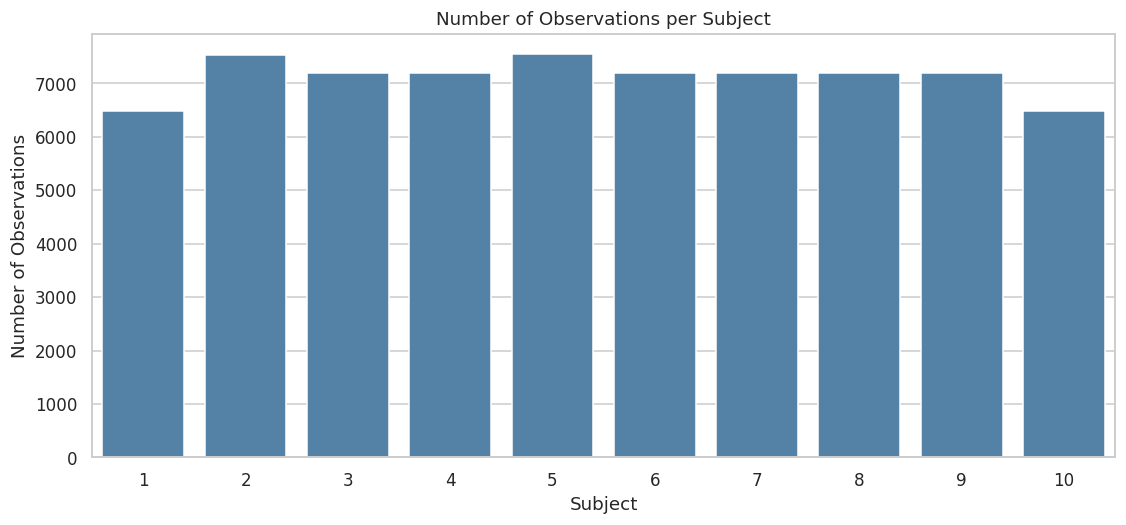

In [18]:
# Visualize the number of observations per subject
sns.barplot(
    data=subject_summary,
    x="Subject",
    y="Number_of_Rows",
    color="steelblue",
)

plt.title("Number of Observations per Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Observations")
plt.show()

In [19]:
# Calculate missing-value statistics for every column
missing_summary = pd.DataFrame({
    "Missing Count": data.isna().sum(),
    "Missing Percentage": data.isna().mean() * 100,
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

display(missing_summary)

,Missing Count,Missing Percentage
right wrist Acceleration,3960,5.558051
right wrist electrodermal,3960,5.558051
right wrist Temperature,3960,5.558051


In [20]:
# Calculate missing-value counts per subject and signal
missing_by_subject = (
    data.groupby("Subject")[INPUT_SIGNALS]
    .apply(lambda frame: frame.isna().sum())
)

display(missing_by_subject)

,Waist Acceleration,Chest Acceleration,Left Ankle Acceleration,right Ankle Acceleration,left wrist Acceleration,right wrist Acceleration,EMG_magnitude_left,EMG_magnitude_right,left wrist electrodermal,right wrist electrodermal,left wrist Temperature,right wrist Temperature,Breath Frequency,Minute Ventilation,SpO2,Heart Rate
Subject,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,3960,0,0,0,3960,0,3960,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


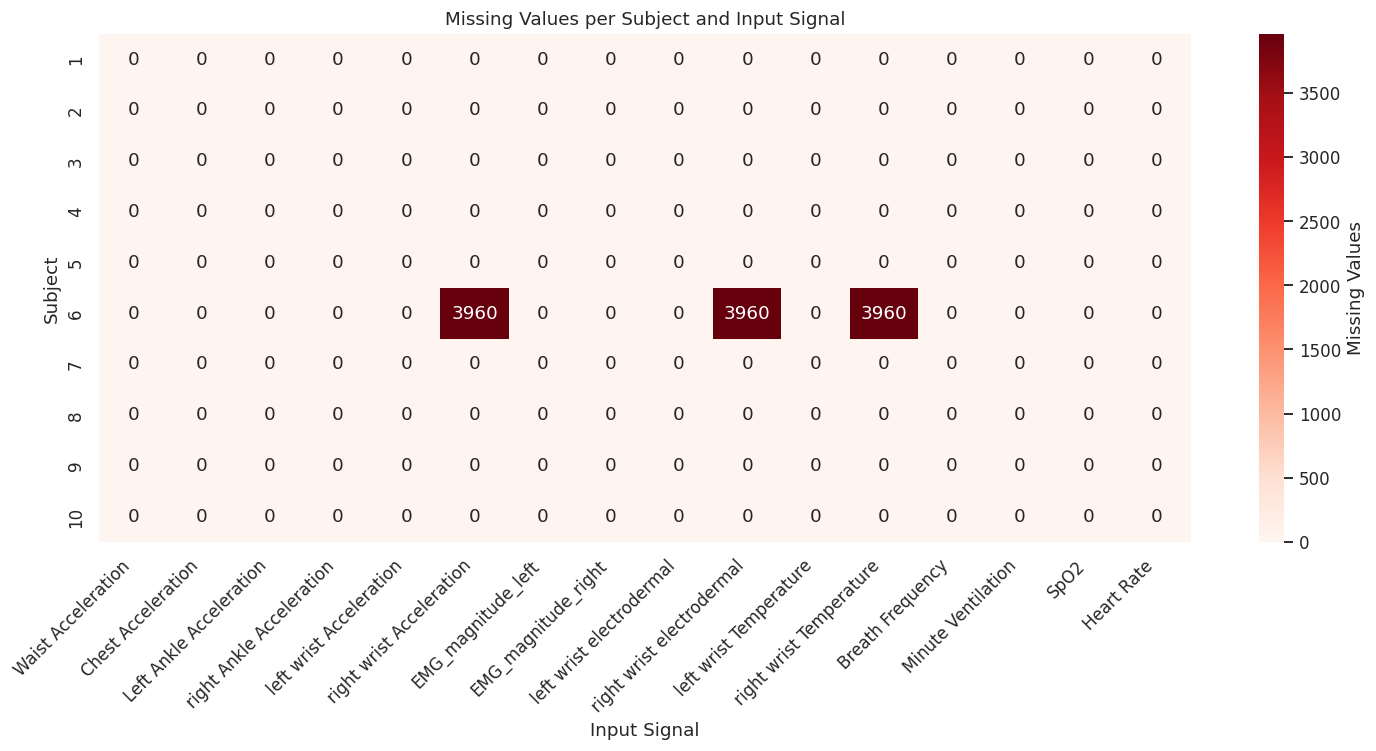

In [21]:
# Visualize missing values by subject and signal
plt.figure(figsize=(16, 6))

sns.heatmap(
    missing_by_subject,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Missing Values"},
)

plt.title("Missing Values per Subject and Input Signal")
plt.xlabel("Input Signal")
plt.ylabel("Subject")
plt.xticks(rotation=45, ha="right")
plt.show()

In [22]:
# Count observations for each activity and subject
activity_subject_counts = pd.crosstab(
    data[ACTIVITY_COLUMN],
    data["Subject"],
)

display(activity_subject_counts)

Subject,1,2,3,4,5,6,7,8,9,10
Activity Code,,,,,,,,,,
1,360,360,360,360,360,360,360,360,360,360
2,360,360,360,360,360,360,360,360,360,360
3,360,355,360,361,360,360,360,360,360,360
4,360,360,360,360,360,360,360,360,360,360
5,360,360,360,360,360,360,360,360,360,360
6,360,360,360,360,360,360,360,360,360,360
7,360,341,360,360,360,360,360,360,360,360
8,360,360,360,360,360,360,360,360,360,360
9,360,360,360,360,360,360,360,360,360,360


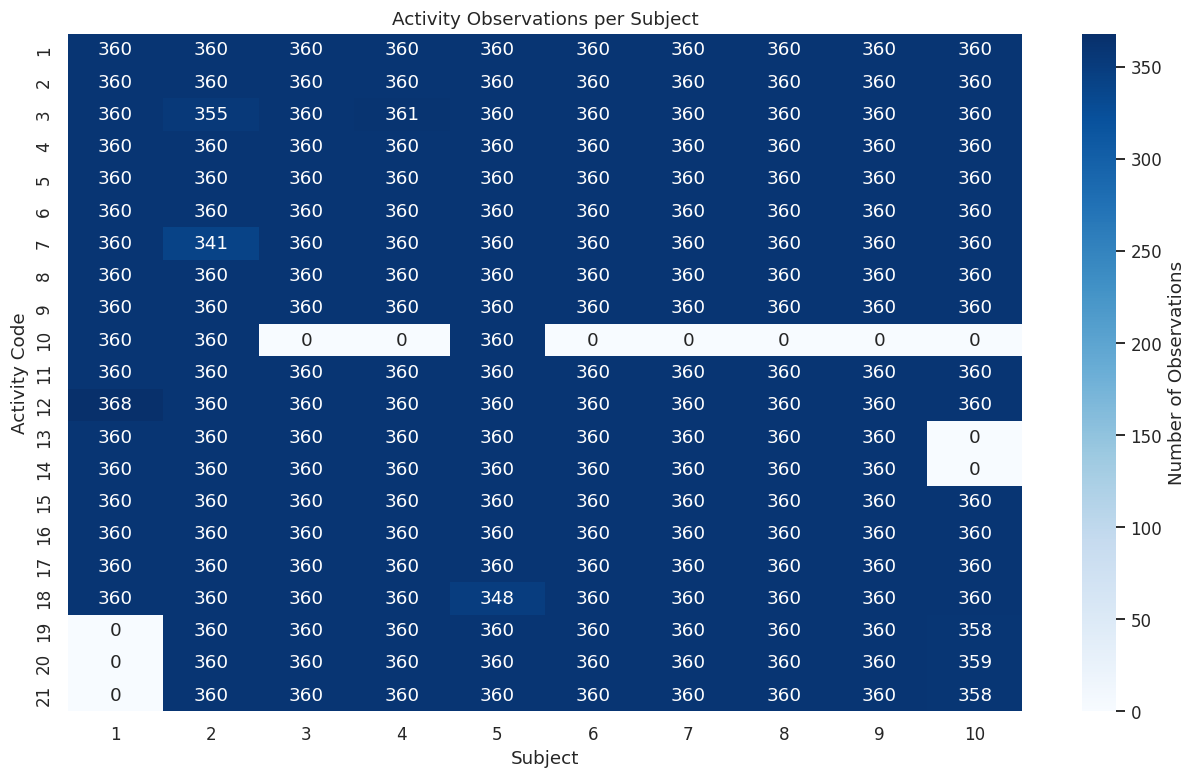

In [23]:
# Visualize the activity distribution across subjects
plt.figure(figsize=(14, 8))

sns.heatmap(
    activity_subject_counts,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Number of Observations"},
)

plt.title("Activity Observations per Subject")
plt.xlabel("Subject")
plt.ylabel("Activity Code")
plt.show()

In [24]:
# Sort rows while preserving their original order within each subject file
data = data.sort_values(["Subject", data.index.name or "Subject"]).reset_index(drop=True)

# Calculate time differences within each subject
data["Time Difference"] = data.groupby("Subject")[TIME_COLUMN].diff()

# Inspect the most common positive time differences
positive_time_differences = data.loc[
    data["Time Difference"] > 0,
    "Time Difference",
]

display(positive_time_differences.describe())

count    71187.000000
mean         1.055895
std          4.496724
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        380.000000
Name: Time Difference, dtype: float64

In [26]:
# Define the maximum accepted time gap between consecutive observations
MAX_TIME_GAP = 1.5

# Detect changes between consecutive rows
subject_changed = data["Subject"].ne(data["Subject"].shift())
activity_changed = data[ACTIVITY_COLUMN].ne(data[ACTIVITY_COLUMN].shift())
time_moved_backwards = data["Time Difference"].le(0)
time_gap_too_large = data["Time Difference"].gt(MAX_TIME_GAP)

# Mark the start of every independent continuous segment
data["New Segment"] = (
    subject_changed
    | activity_changed
    | time_moved_backwards
    | time_gap_too_large
)

# Assign a unique ID to every segment
data["Segment ID"] = data["New Segment"].cumsum()

print(f"Detected segments: {data['Segment ID'].nunique()}")

Detected segments: 198


In [27]:
# Summarize every continuous activity segment
segment_summary = (
    data.groupby("Segment ID")
    .agg(
        Subject=("Subject", "first"),
        Activity_Code=(ACTIVITY_COLUMN, "first"),
        Number_of_Rows=(TARGET_COLUMN, "size"),
        Start_Time=(TIME_COLUMN, "first"),
        End_Time=(TIME_COLUMN, "last"),
        Mean_EE=(TARGET_COLUMN, "mean"),
        Missing_Values=(TARGET_COLUMN, lambda x: 0),
    )
    .reset_index()
)

# Calculate missing values across all input signals per segment
segment_missing = data.groupby("Segment ID")[INPUT_SIGNALS].apply(
    lambda frame: frame.isna().sum().sum()
)

segment_summary["Missing_Values"] = segment_summary["Segment ID"].map(
    segment_missing
)

display(segment_summary.head(20))
display(segment_summary["Number_of_Rows"].describe())

,Segment ID,Subject,Activity_Code,Number_of_Rows,Start_Time,End_Time,Mean_EE,Missing_Values
0,1,1,1,360,360.000000,719.000000,1.889876,0
1,2,1,3,360,720.000000,1079.000000,2.329367,0
2,3,1,2,360,1080.000000,1439.000000,0.969828,0
3,4,1,5,360,360.007812,719.007812,4.600323,0
4,5,1,4,360,720.007812,1079.007812,2.214446,0
5,6,1,6,360,1440.007812,1799.007812,3.585470,0
6,7,1,7,360,1800.007812,2159.007812,7.694861,0
7,8,1,8,360,360.007812,719.007812,1.451302,0
8,9,1,9,360,720.007812,1079.007812,2.528274,0
9,10,1,10,360,1080.007812,1439.007812,3.554271,0


count    198.000000
mean     359.838384
std        1.743484
min      341.000000
25%      360.000000
50%      360.000000
75%      360.000000
max      368.000000
Name: Number_of_Rows, dtype: float64

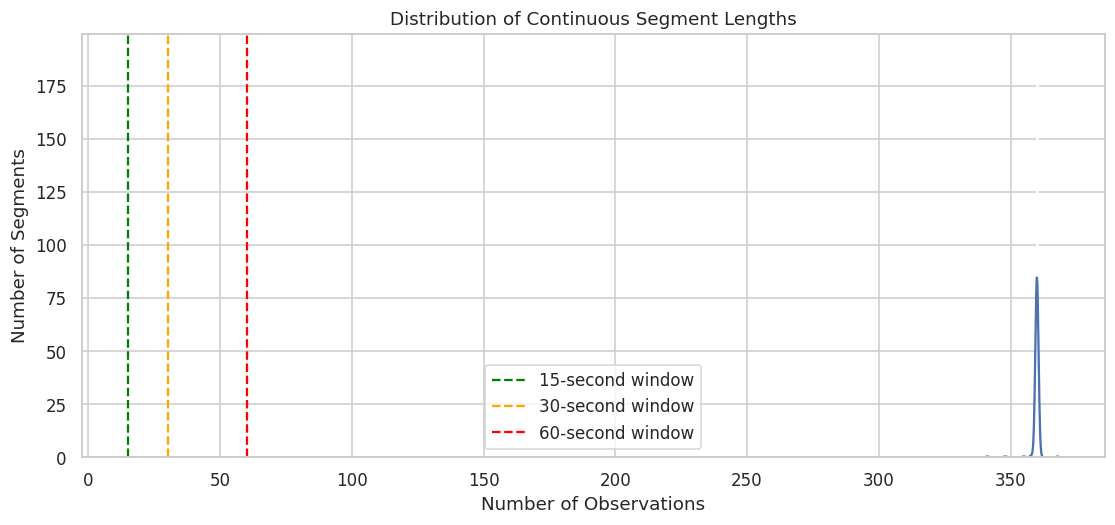

In [28]:
# Visualize the distribution of continuous segment lengths
sns.histplot(
    data=segment_summary,
    x="Number_of_Rows",
    bins=40,
    kde=True,
)

plt.axvline(15, color="green", linestyle="--", label="15-second window")
plt.axvline(30, color="orange", linestyle="--", label="30-second window")
plt.axvline(60, color="red", linestyle="--", label="60-second window")

plt.title("Distribution of Continuous Segment Lengths")
plt.xlabel("Number of Observations")
plt.ylabel("Number of Segments")
plt.legend()
plt.show()

In [29]:
def count_possible_windows(segment_lengths, window_size, step_size):
    """Count windows that fit completely inside continuous segments."""
    windows_per_segment = np.maximum(
        ((segment_lengths - window_size) // step_size) + 1,
        0,
    )

    return int(windows_per_segment.sum())


window_options = []

for window_size in [15, 30, 60]:
    for step_size in [1, 5, 10]:
        number_of_windows = count_possible_windows(
            segment_summary["Number_of_Rows"].to_numpy(),
            window_size,
            step_size,
        )

        window_options.append({
            "Window Size": window_size,
            "Step Size": step_size,
            "Possible Windows": number_of_windows,
        })

window_options = pd.DataFrame(window_options)

display(window_options)

,Window Size,Step Size,Possible Windows
0,15,1,68476
1,15,5,13850
2,15,10,6928
3,30,1,65506
4,30,5,13256
5,30,10,6724
6,60,1,59566
7,60,5,12068
8,60,10,6130


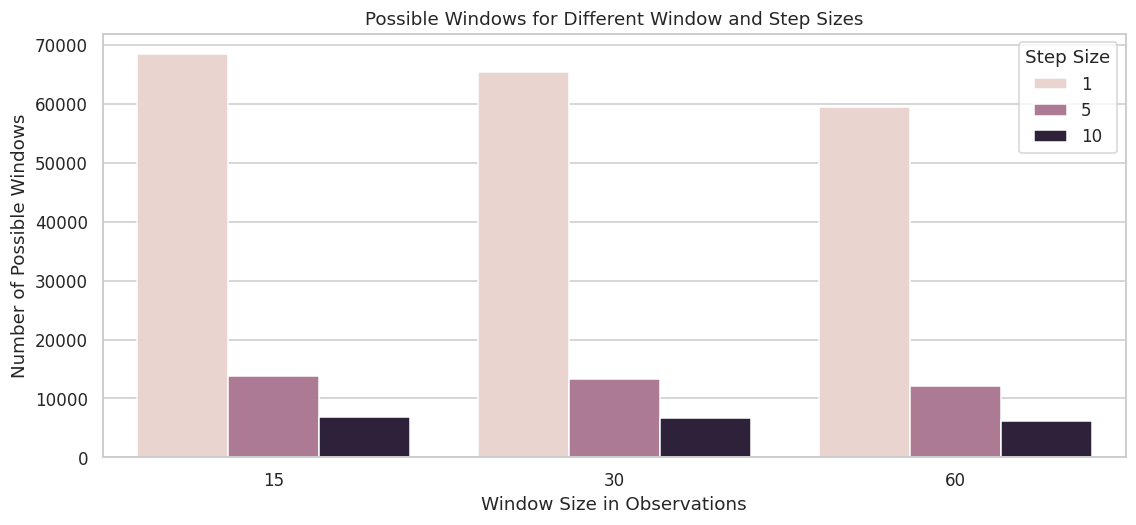

In [30]:
# Visualize the number of possible windows
sns.barplot(
    data=window_options,
    x="Window Size",
    y="Possible Windows",
    hue="Step Size",
)

plt.title("Possible Windows for Different Window and Step Sizes")
plt.xlabel("Window Size in Observations")
plt.ylabel("Number of Possible Windows")
plt.show()

In [31]:
# Display descriptive statistics for the regression target
display(data[TARGET_COLUMN].describe())

count    71248.000000
mean         5.301778
std          3.067269
min          0.969828
25%          2.825588
50%          4.793772
75%          6.564081
max         15.178307
Name: Energy expenditures (W/kg), dtype: float64

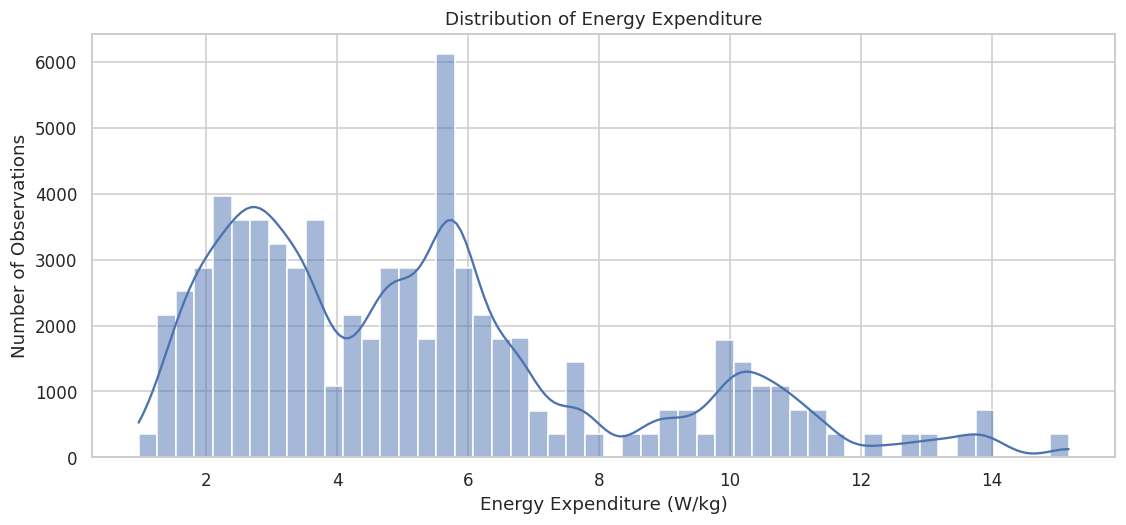

In [32]:
# Visualize the overall target distribution
sns.histplot(
    data=data,
    x=TARGET_COLUMN,
    bins=50,
    kde=True,
)

plt.title("Distribution of Energy Expenditure")
plt.xlabel("Energy Expenditure (W/kg)")
plt.ylabel("Number of Observations")
plt.show()

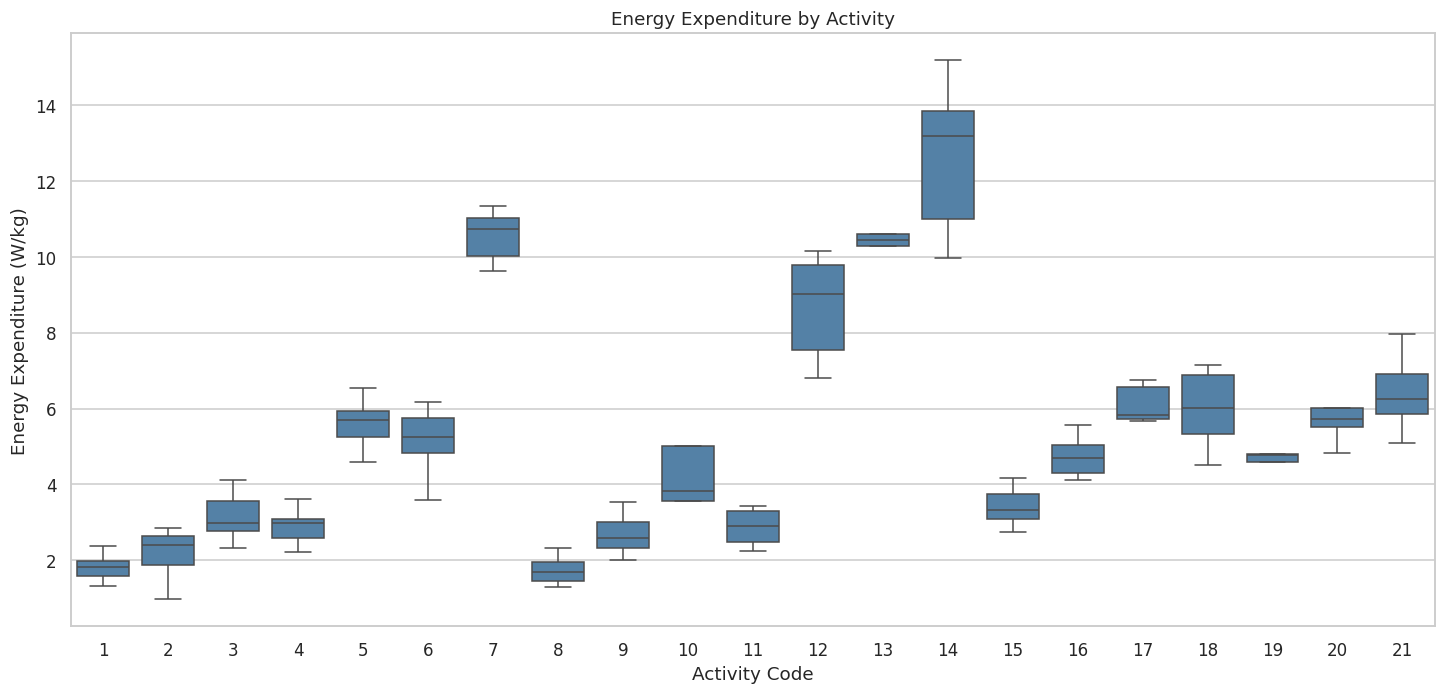

In [33]:
# Compare energy expenditure distributions between activities
plt.figure(figsize=(16, 7))

sns.boxplot(
    data=data,
    x=ACTIVITY_COLUMN,
    y=TARGET_COLUMN,
    color="steelblue",
    showfliers=False,
)

plt.title("Energy Expenditure by Activity")
plt.xlabel("Activity Code")
plt.ylabel("Energy Expenditure (W/kg)")
plt.show()

In [34]:
# Calculate correlations between signals and the target
correlation_columns = INPUT_SIGNALS + [LEAKAGE_COLUMN, TARGET_COLUMN]

correlations = (
    data[correlation_columns]
    .corr()[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values()
)

display(correlations.to_frame("Correlation with Energy Expenditure"))

,Correlation with Energy Expenditure
SpO2,-0.422275
right wrist Temperature,-0.094742
left wrist Temperature,-0.011062
left wrist electrodermal,0.208620
right wrist electrodermal,0.285375
EMG_magnitude_left,0.377908
EMG_magnitude_right,0.445808
Breath Frequency,0.486769
right wrist Acceleration,0.561444
left wrist Acceleration,0.589370


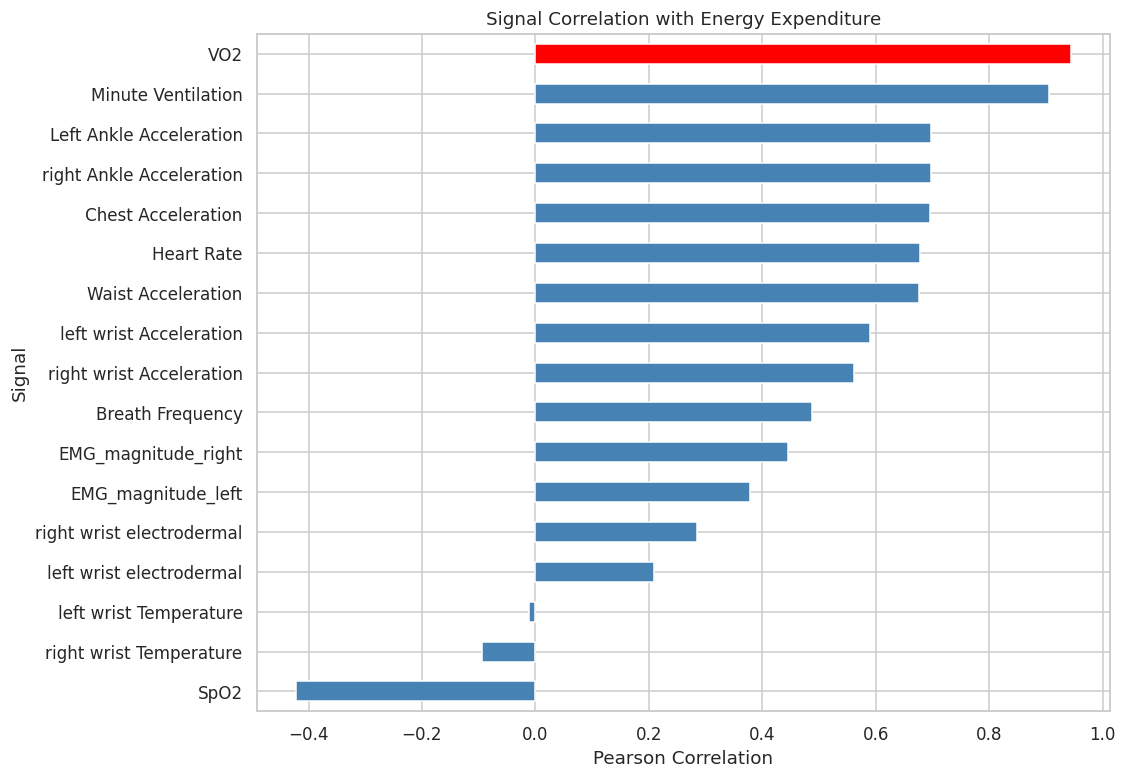

In [35]:
# Visualize signal correlations with the target
correlation_colors = [
    "red" if signal == LEAKAGE_COLUMN else "steelblue"
    for signal in correlations.index
]

correlations.plot(
    kind="barh",
    color=correlation_colors,
    figsize=(10, 8),
)

plt.title("Signal Correlation with Energy Expenditure")
plt.xlabel("Pearson Correlation")
plt.ylabel("Signal")
plt.show()

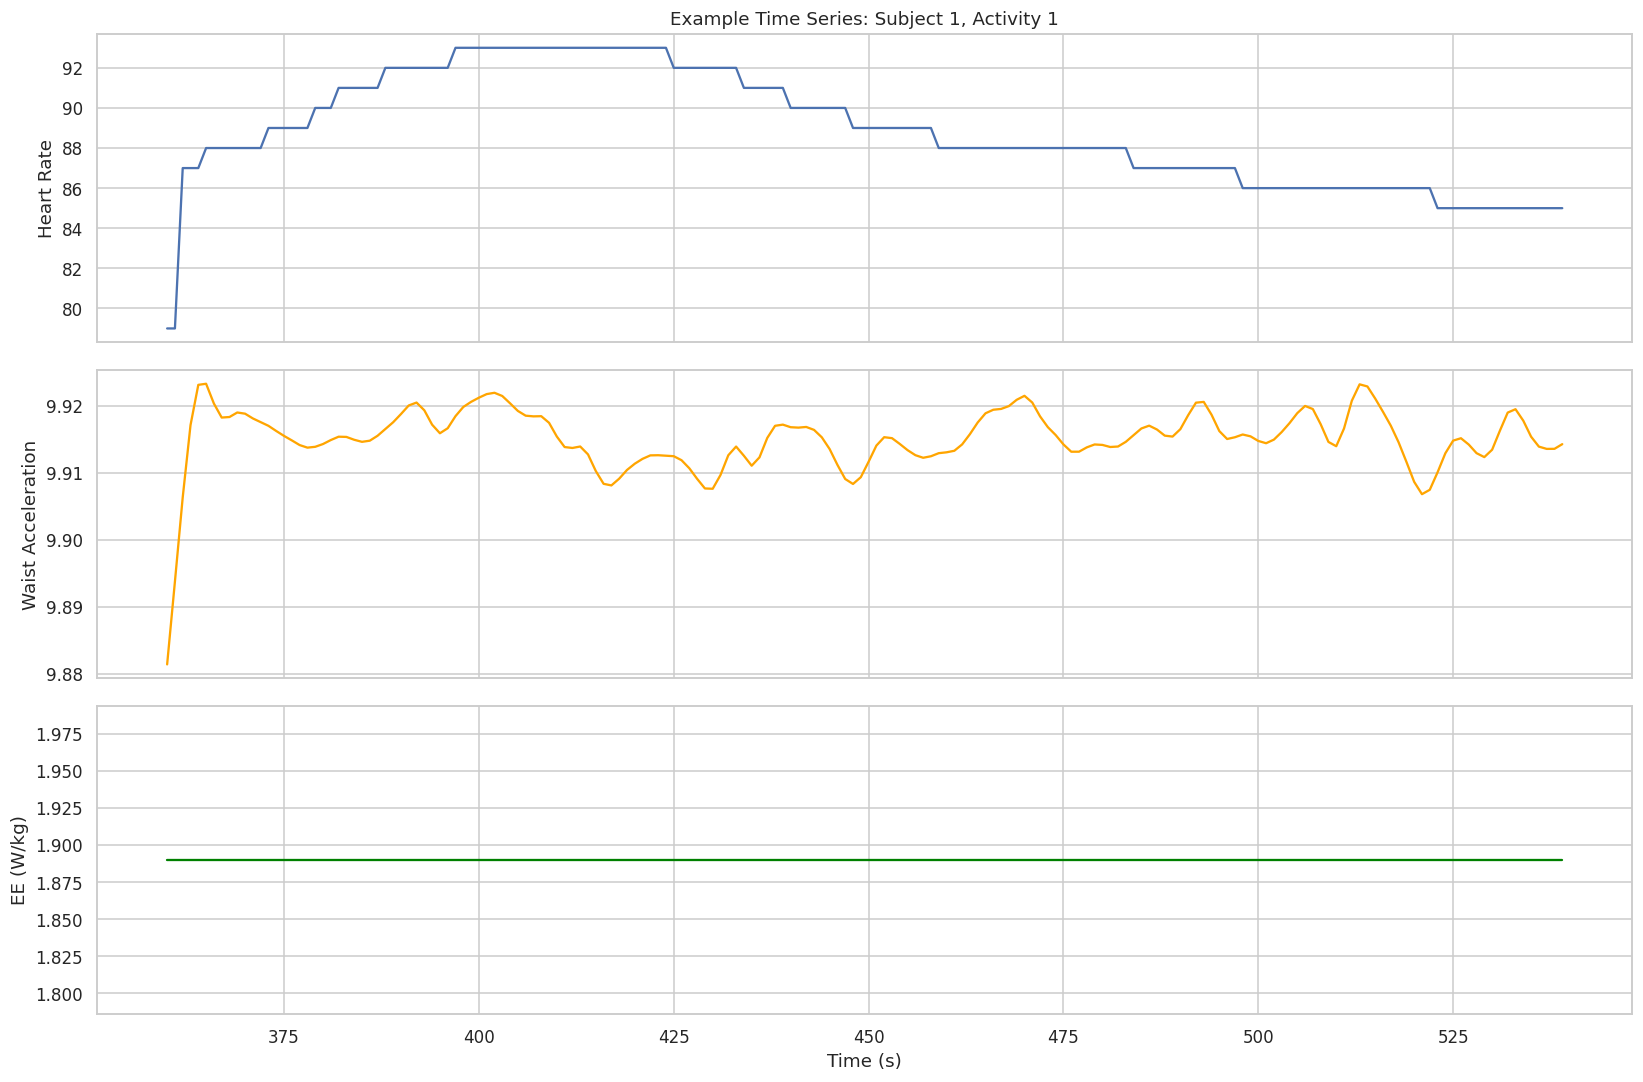

In [36]:
# Select one example subject and activity
EXAMPLE_SUBJECT = 1
EXAMPLE_ACTIVITY = 1

example_data = data[
    (data["Subject"] == EXAMPLE_SUBJECT)
    & (data[ACTIVITY_COLUMN] == EXAMPLE_ACTIVITY)
].head(180)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(
    example_data[TIME_COLUMN],
    example_data["Heart Rate"],
)
axes[0].set_ylabel("Heart Rate")
axes[0].set_title(
    f"Example Time Series: Subject {EXAMPLE_SUBJECT}, "
    f"Activity {EXAMPLE_ACTIVITY}"
)

axes[1].plot(
    example_data[TIME_COLUMN],
    example_data["Waist Acceleration"],
    color="orange",
)
axes[1].set_ylabel("Waist Acceleration")

axes[2].plot(
    example_data[TIME_COLUMN],
    example_data[TARGET_COLUMN],
    color="green",
)
axes[2].set_ylabel("EE (W/kg)")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [37]:
# Select one continuous segment that is long enough
WINDOW_SIZE = 30

valid_segment_ids = segment_summary.loc[
    segment_summary["Number_of_Rows"] >= WINDOW_SIZE,
    "Segment ID",
]

example_segment_id = valid_segment_ids.iloc[0]

example_window = (
    data[data["Segment ID"] == example_segment_id]
    .iloc[:WINDOW_SIZE]
)

window_target = example_window[TARGET_COLUMN].mean()

print(f"Example segment ID: {example_segment_id}")
print(f"Window shape: {example_window[INPUT_SIGNALS].shape}")
print(f"Mean target value: {window_target:.3f} W/kg")

display(example_window[[TIME_COLUMN, "Heart Rate", TARGET_COLUMN]].head())

Example segment ID: 1
Window shape: (30, 16)
Mean target value: 1.890 W/kg


,Time (s),Heart Rate,Energy expenditures (W/kg)
0,360.0,79.0,1.889876
1,361.0,79.0,1.889876
2,362.0,87.0,1.889876
3,363.0,87.0,1.889876
4,364.0,87.0,1.889876


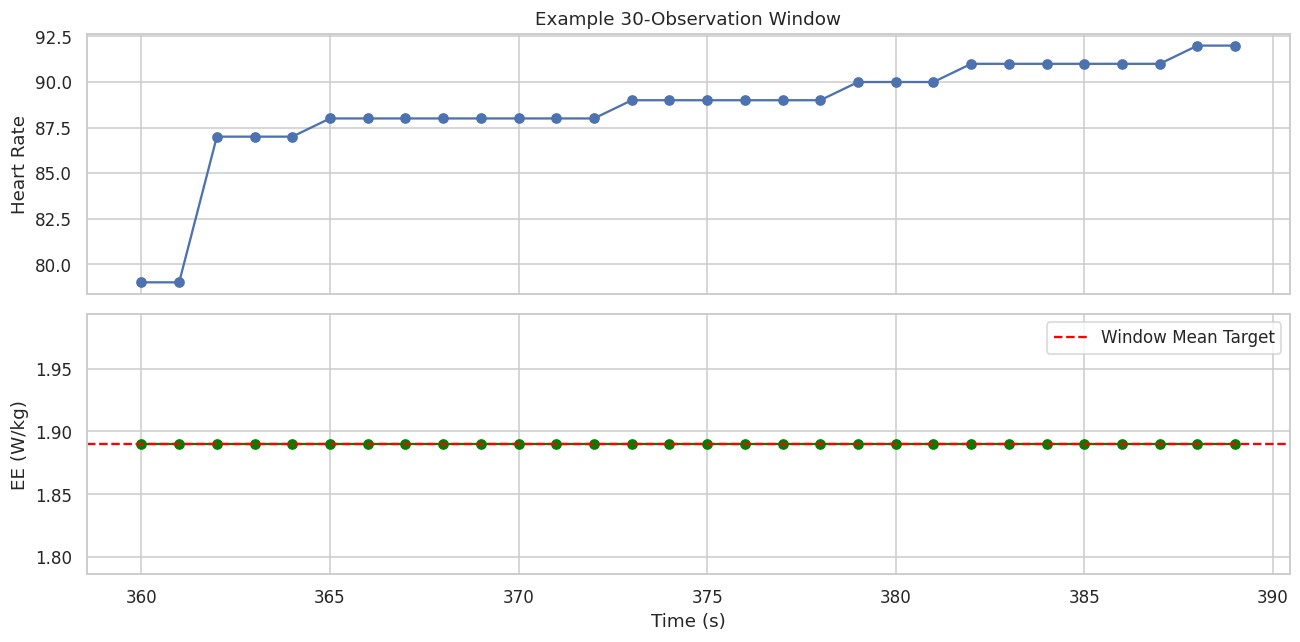

In [38]:
# Visualize heart rate and target inside one possible model window
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(
    example_window[TIME_COLUMN],
    example_window["Heart Rate"],
    marker="o",
)
axes[0].set_ylabel("Heart Rate")
axes[0].set_title("Example 30-Observation Window")

axes[1].plot(
    example_window[TIME_COLUMN],
    example_window[TARGET_COLUMN],
    marker="o",
    color="green",
)
axes[1].axhline(
    window_target,
    color="red",
    linestyle="--",
    label="Window Mean Target",
)
axes[1].set_ylabel("EE (W/kg)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# Create a compact final analysis summary
analysis_summary = {
    "Number of Subjects": data["Subject"].nunique(),
    "Number of Rows": len(data),
    "Number of Activities": data[ACTIVITY_COLUMN].nunique(),
    "Number of Continuous Segments": data["Segment ID"].nunique(),
    "Total Missing Input Values": int(data[INPUT_SIGNALS].isna().sum().sum()),
    "Minimum Target Value": data[TARGET_COLUMN].min(),
    "Maximum Target Value": data[TARGET_COLUMN].max(),
    "Mean Target Value": data[TARGET_COLUMN].mean(),
}

display(
    pd.DataFrame.from_dict(
        analysis_summary,
        orient="index",
        columns=["Value"],
    )
)

,Value
Number of Subjects,10.000000
Number of Rows,71248.000000
Number of Activities,21.000000
Number of Continuous Segments,198.000000
Total Missing Input Values,11880.000000
Minimum Target Value,0.969828
Maximum Target Value,15.178307
Mean Target Value,5.301778


,Subject,Number of Windows
0,1,1207
1,2,1402
2,3,1340
3,4,1340
4,5,1404
5,6,1340
6,7,1340
7,8,1340
8,9,1340
9,10,1203


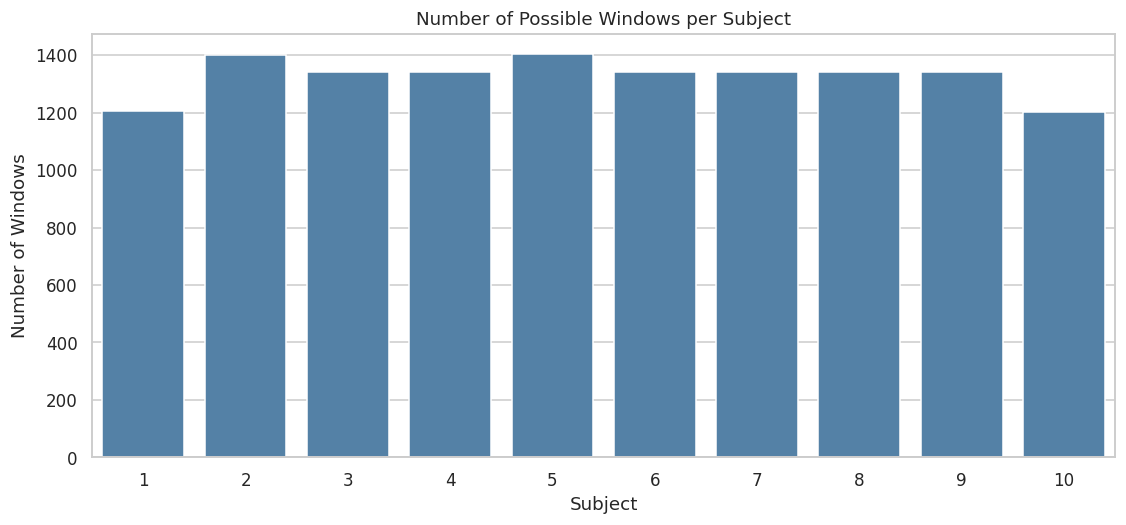

In [40]:
def count_windows_per_group(
    frame,
    group_columns,
    window_size,
    step_size,
):
    """Count possible windows inside each continuous segment."""
    segment_lengths = (
        frame.groupby(group_columns)
        .size()
        .rename("Segment Length")
        .reset_index()
    )

    segment_lengths["Number of Windows"] = np.maximum(
        ((segment_lengths["Segment Length"] - window_size) // step_size) + 1,
        0,
    )

    return segment_lengths


# Compare the number of 30-second windows available per subject
window_counts = count_windows_per_group(
    data,
    group_columns=["Subject", "Segment ID"],
    window_size=30,
    step_size=5,
)

windows_per_subject = (
    window_counts.groupby("Subject")["Number of Windows"]
    .sum()
    .reset_index()
)

display(windows_per_subject)

sns.barplot(
    data=windows_per_subject,
    x="Subject",
    y="Number of Windows",
    color="steelblue",
)

plt.title("Number of Possible Windows per Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Windows")
plt.show()

In [41]:
# Check whether the target is constant inside every continuous segment
target_values_per_segment = (
    data.groupby("Segment ID")[TARGET_COLUMN]
    .nunique()
)

print(target_values_per_segment.value_counts())
print(
    "All segments have a constant target:",
    target_values_per_segment.eq(1).all(),
)

Energy expenditures (W/kg)
1    198
Name: count, dtype: int64
All segments have a constant target: True
